# Задание 2.1 - Нейронные сети

В этом задании вы реализуете и натренируете настоящую нейроную сеть своими руками!

В некотором смысле это будет расширением прошлого задания - нам нужно просто составить несколько линейных классификаторов вместе!

<img src="https://i.redd.it/n9fgba8b0qr01.png" alt="Stack_more_layers" width="400px"/>

In [74]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
from dataset import load_svhn, random_split_train_val
from gradient_check import check_layer_gradient, check_layer_param_gradient, check_model_gradient
from layers import FullyConnectedLayer, ReLULayer
from model import TwoLayerNet
from trainer import Trainer, Dataset
from optim import SGD, MomentumSGD
from metrics import multiclass_accuracy

# Загружаем данные

И разделяем их на training и validation.

In [76]:
def prepare_for_neural_network(train_X, test_X):
    train_flat = train_X.reshape(train_X.shape[0], -1).astype(np.float64) / 255.0
    test_flat = test_X.reshape(test_X.shape[0], -1).astype(np.float64) / 255.0
    
    # Subtract mean
    mean_image = np.mean(train_flat, axis = 0)
    train_flat -= mean_image
    test_flat -= mean_image
    
    return train_flat, test_flat
    
train_X, train_y, test_X, test_y = load_svhn("data", max_train=10000, max_test=1000)    
train_X, test_X = prepare_for_neural_network(train_X, test_X)
# Split train into train and val
train_X, train_y, val_X, val_y = random_split_train_val(train_X, train_y, num_val = 1000)

# Как всегда, начинаем с кирпичиков

Мы будем реализовывать необходимые нам слои по очереди. Каждый слой должен реализовать:
- прямой проход (forward pass), который генерирует выход слоя по входу и запоминает необходимые данные
- обратный проход (backward pass), который получает градиент по выходу слоя и вычисляет градиент по входу и по параметрам

Начнем с ReLU, у которого параметров нет.

In [77]:
X = np.array([[1,-2,3],
              [-1, 2, 0.1]
              ])

assert check_layer_gradient(ReLULayer(), X)

Gradient check passed!


А теперь реализуем полносвязный слой (fully connected layer), у которого будет два массива параметров: W (weights) и B (bias).

Все параметры наши слои будут использовать для параметров специальный класс `Param`, в котором будут храниться значения параметров и градиенты этих параметров, вычисляемые во время обратного прохода.

Это даст возможность аккумулировать (суммировать) градиенты из разных частей функции потерь, например, из cross-entropy loss и regularization loss.

In [78]:
assert check_layer_gradient(FullyConnectedLayer(3, 4), X)

assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'W')
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'B')

Gradient check passed!
Gradient check passed!
Gradient check passed!


## Создаем нейронную сеть

Теперь мы реализуем простейшую нейронную сеть с двумя полносвязным слоями и нелинейностью ReLU. Реализуйте функцию `compute_loss_and_gradients`, она должна запустить прямой и обратный проход через оба слоя для вычисления градиентов.

Не забудьте реализовать очистку градиентов в начале функции.

In [79]:
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 3, reg = 0)
loss = model.compute_loss_and_gradients(train_X[:2], train_y[:2])

check_model_gradient(model, train_X[:2], train_y[:2])

Checking gradient for hidden_W
Gradient check passed!
Checking gradient for hidden_B
Gradient check passed!
Checking gradient for output_W
Gradient check passed!
Checking gradient for output_B
Gradient check passed!


True

Теперь добавьте к модели регуляризацию - она должна прибавляться к loss и делать свой вклад в градиенты.

In [ ]:
model_with_reg = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 3, reg = 1e1)
loss_with_reg = model_with_reg.compute_loss_and_gradients(train_X[:2], train_y[:2])
assert loss_with_reg > loss and not np.isclose(loss_with_reg, loss), \
    "Loss with regularization (%2.4f) should be higher than without it (%2.4f)!" % (loss, loss_with_reg)

check_model_gradient(model_with_reg, train_X[:2], train_y[:2])

Checking gradient for hidden_W
Gradient check passed!
Checking gradient for hidden_B
Gradient check passed!
Checking gradient for output_W
Gradient check passed!
Checking gradient for output_B
Gradient check passed!


True

Также реализуем функцию предсказания (вычисления значения) модели на новых данных.

Какое значение точности мы ожидаем увидеть до начала тренировки?

In [ ]:
multiclass_accuracy(model_with_reg.predict(train_X[:30]), train_y[:30]) 

np.float64(0.1)

# Допишем код для процесса тренировки

Если все реализовано корректно, значение функции ошибки должно уменьшаться с каждой эпохой, пусть и медленно. Не беспокойтесь пока про validation accuracy.

In [ ]:
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-3)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, SGD(), learning_rate = 1e-2)

loss_history, train_history, val_history = trainer.fit()

Loss: 2.216706, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.154270, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.100071, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.286345, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.169583, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.064616, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.368611, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.111779, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.226791, Train accuracy: 0.207222, val accuracy: 0.215000
Loss: 2.069778, Train accuracy: 0.230333, val accuracy: 0.235000
Loss: 2.121233, Train accuracy: 0.257222, val accuracy: 0.258000
Loss: 2.110917, Train accuracy: 0.269000, val accuracy: 0.268000
Loss: 2.121928, Train accuracy: 0.282889, val accuracy: 0.287000
Loss: 2.001790, Train accuracy: 0.299556, val accuracy: 0.303000
Loss: 2.056521, Train accuracy: 0.323222, val accuracy: 0.323000
Loss: 1.858225, Train acc

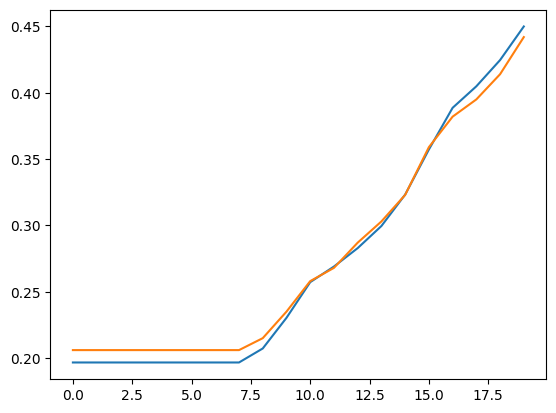

In [83]:
plt.plot(train_history)
plt.plot(val_history)

# Улучшаем процесс тренировки

Мы реализуем несколько ключевых оптимизаций, необходимых для тренировки современных нейросетей.

## Уменьшение скорости обучения (learning rate decay)

Одна из необходимых оптимизаций во время тренировки нейронных сетей - постепенное уменьшение скорости обучения по мере тренировки.

Один из стандартных методов - уменьшение скорости обучения (learning rate) каждые N эпох на коэффициент d (часто называемый decay). Значения N и d, как всегда, являются гиперпараметрами и должны подбираться на основе эффективности на проверочных данных (validation data). 

В нашем случае N будет равным 1.

In [ ]:
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-3)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, SGD(), learning_rate_decay=0.99)

initial_learning_rate = trainer.learning_rate
loss_history, train_history, val_history = trainer.fit()

assert trainer.learning_rate < initial_learning_rate, "Learning rate should've been reduced"
assert trainer.learning_rate > 0.5*initial_learning_rate, "Learning rate shouldn'tve been reduced that much!"

Loss: 2.245684, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.372685, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.208299, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.259444, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.181578, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.193982, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.085672, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.321907, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.251000, Train accuracy: 0.200556, val accuracy: 0.208000
Loss: 2.196621, Train accuracy: 0.225333, val accuracy: 0.230000
Loss: 2.084484, Train accuracy: 0.241222, val accuracy: 0.242000
Loss: 2.095548, Train accuracy: 0.268222, val accuracy: 0.267000
Loss: 2.380465, Train accuracy: 0.277000, val accuracy: 0.272000
Loss: 1.767388, Train accuracy: 0.280444, val accuracy: 0.285000
Loss: 2.304647, Train accuracy: 0.299778, val accuracy: 0.307000
Loss: 1.941685, Train acc

# Накопление импульса (Momentum SGD)

Другой большой класс оптимизаций - использование более эффективных методов градиентного спуска. Мы реализуем один из них - накопление импульса (Momentum SGD).

Этот метод хранит скорость движения, использует градиент для ее изменения на каждом шаге, и изменяет веса пропорционально значению скорости.
(Физическая аналогия: Вместо скорости градиенты теперь будут задавать ускорение, но будет присутствовать сила трения.)

```
velocity = momentum * velocity - learning_rate * gradient 
w = w + velocity
```

`momentum` здесь коэффициент затухания, который тоже является гиперпараметром (к счастью, для него часто есть хорошее значение по умолчанию, типичный диапазон -- 0.8-0.99).

Несколько полезных ссылок, где метод разбирается более подробно:  
http://cs231n.github.io/neural-networks-3/#sgd  
https://distill.pub/2017/momentum/

In [85]:
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-3)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=1e-2, learning_rate_decay=0.99)

# You should see even better results than before!
loss_history, train_history, val_history = trainer.fit()

Loss: 2.153337, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 1.677622, Train accuracy: 0.344556, val accuracy: 0.355000
Loss: 1.395326, Train accuracy: 0.534444, val accuracy: 0.535000
Loss: 1.458161, Train accuracy: 0.601778, val accuracy: 0.594000
Loss: 1.387373, Train accuracy: 0.665000, val accuracy: 0.655000
Loss: 1.641804, Train accuracy: 0.672889, val accuracy: 0.657000
Loss: 1.006728, Train accuracy: 0.718000, val accuracy: 0.677000
Loss: 1.106447, Train accuracy: 0.706444, val accuracy: 0.660000
Loss: 1.365101, Train accuracy: 0.738222, val accuracy: 0.702000
Loss: 1.401117, Train accuracy: 0.745333, val accuracy: 0.692000
Loss: 0.846030, Train accuracy: 0.769000, val accuracy: 0.693000
Loss: 0.777381, Train accuracy: 0.773444, val accuracy: 0.712000
Loss: 0.852111, Train accuracy: 0.794333, val accuracy: 0.722000
Loss: 0.662009, Train accuracy: 0.773333, val accuracy: 0.711000
Loss: 1.305905, Train accuracy: 0.803000, val accuracy: 0.728000
Loss: 1.131954, Train acc

# Ну что, давайте уже тренировать сеть!

## Последний тест - переобучимся (overfit) на маленьком наборе данных

Хороший способ проверить, все ли реализовано корректно - переобучить сеть на маленьком наборе данных.  
Наша модель обладает достаточной мощностью, чтобы приблизить маленький набор данных идеально, поэтому мы ожидаем, что на нем мы быстро дойдем до 100% точности на тренировочном наборе. 

Если этого не происходит, то где-то была допущена ошибка!

In [86]:
data_size = 15
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(train_X[:data_size], train_y[:data_size], val_X[:data_size], val_y[:data_size])
trainer = Trainer(model, dataset, SGD(), learning_rate=1e-1, num_epochs=150, batch_size=5)

# You should expect this to reach 1.0 training accuracy 
loss_history, train_history, val_history = trainer.fit()

Loss: 2.351618, Train accuracy: 0.266667, val accuracy: 0.066667
Loss: 2.318467, Train accuracy: 0.266667, val accuracy: 0.066667
Loss: 2.291136, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.341864, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 2.302463, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.319034, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.235521, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 2.170412, Train accuracy: 0.266667, val accuracy: 0.000000
Loss: 2.144598, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 2.000302, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.842682, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 2.238035, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.616099, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 2.203432, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.902569, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.637197, Train acc

Теперь найдем гипепараметры, для которых этот процесс сходится быстрее.
Если все реализовано корректно, то существуют параметры, при которых процесс сходится в **20** эпох или еще быстрее.
Найдите их!

In [87]:
# Now, tweak some hyper parameters and make it train to 1.0 accuracy in 20 epochs or less

model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-3)
dataset = Dataset(train_X[:data_size], train_y[:data_size], val_X[:data_size], val_y[:data_size])
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=1e-1, num_epochs=20, batch_size=5)

loss_history, train_history, val_history = trainer.fit()

Loss: 2.297329, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 2.274156, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 2.114349, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 2.174350, Train accuracy: 0.333333, val accuracy: 0.066667
Loss: 2.124066, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 1.582494, Train accuracy: 0.333333, val accuracy: 0.066667
Loss: 1.408680, Train accuracy: 0.466667, val accuracy: 0.066667
Loss: 1.613785, Train accuracy: 0.600000, val accuracy: 0.000000
Loss: 1.893010, Train accuracy: 0.600000, val accuracy: 0.066667
Loss: 1.556345, Train accuracy: 0.733333, val accuracy: 0.066667
Loss: 0.914335, Train accuracy: 0.800000, val accuracy: 0.000000
Loss: 0.611559, Train accuracy: 0.933333, val accuracy: 0.066667
Loss: 0.080779, Train accuracy: 1.000000, val accuracy: 0.066667
Loss: 0.144094, Train accuracy: 1.000000, val accuracy: 0.000000
Loss: 0.121064, Train accuracy: 1.000000, val accuracy: 0.000000
Loss: 0.097576, Train acc

# Итак, основное мероприятие!

Натренируйте лучшую нейросеть! Можно добавлять и изменять параметры, менять количество нейронов в слоях сети и как угодно экспериментировать. 

Добейтесь точности лучше **60%** на validation set.

In [88]:
# Let's train the best one-hidden-layer network we can

learning_rate = 1e-2
reg_strength = 1e-3
learning_rate_decay = 0.999
hidden_layer_size = 256
num_epochs = 50
batch_size = 64

best_classifier = None
best_val_accuracy = None

loss_history = []
train_history = []
val_history = []

# TODO find the best hyperparameters to train the network
# Don't hesitate to add new values to the arrays above, perform experiments, use any tricks you want
# You should expect to get to at least 40% of valudation accuracy
# Save loss/train/history of the best classifier to the variables above

model = TwoLayerNet(n_input=train_X.shape[1], n_output=10, hidden_layer_size=hidden_layer_size, reg=reg_strength)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, MomentumSGD(), num_epochs, batch_size, learning_rate, learning_rate_decay)

loss_history, train_history, val_history = trainer.fit()
best_val_accuracy = np.max(val_history)
best_classifier = model

print('best validation accuracy achieved: %f' % best_val_accuracy)

Loss: 2.244380, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.133912, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.247619, Train accuracy: 0.201556, val accuracy: 0.208000
Loss: 2.020200, Train accuracy: 0.269111, val accuracy: 0.266000
Loss: 1.876886, Train accuracy: 0.359333, val accuracy: 0.361000
Loss: 1.803512, Train accuracy: 0.435000, val accuracy: 0.429000
Loss: 1.493153, Train accuracy: 0.491556, val accuracy: 0.499000
Loss: 1.324297, Train accuracy: 0.555778, val accuracy: 0.554000
Loss: 1.197802, Train accuracy: 0.611111, val accuracy: 0.597000
Loss: 1.328545, Train accuracy: 0.639333, val accuracy: 0.633000
Loss: 1.375822, Train accuracy: 0.660556, val accuracy: 0.647000
Loss: 1.531631, Train accuracy: 0.687000, val accuracy: 0.668000
Loss: 1.359915, Train accuracy: 0.702222, val accuracy: 0.681000
Loss: 1.282492, Train accuracy: 0.700111, val accuracy: 0.684000
Loss: 0.979628, Train accuracy: 0.721778, val accuracy: 0.696000
Loss: 1.059658, Train acc

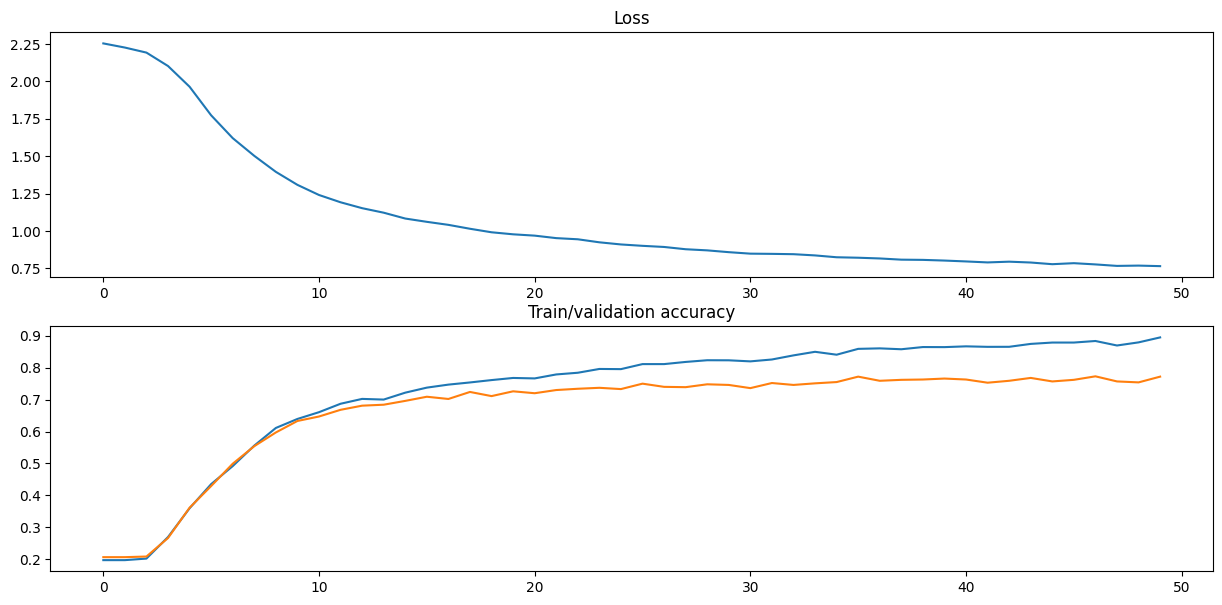

In [89]:
plt.figure(figsize=(15, 7))
plt.subplot(211)
plt.title("Loss")
plt.plot(loss_history)
plt.subplot(212)
plt.title("Train/validation accuracy")
plt.plot(train_history)
plt.plot(val_history)

# Как обычно, посмотрим, как наша лучшая модель работает на тестовых данных

In [90]:
test_pred = best_classifier.predict(test_X)
test_accuracy = multiclass_accuracy(test_pred, test_y)
print('Neural net test set accuracy: %f' % (test_accuracy, ))

Neural net test set accuracy: 0.736000
